# Assigment 2 Learning

<h2 style="text-align:left;">Group 4: Machine</h2>

<table style="margin-left:0;">
  <tr>
    <th>Student’s Full Name</th>
    <th>Registration Number</th>
  </tr>
  <tr><td>BEDAH F. KABEHO</td><td>31678/T.2023</td></tr>
  <tr><td>AMIN S. ISSA</td><td>31030/T.2023</td></tr>
  <tr><td>HEMED Z. MOHAMED</td><td>30352/T.2023</td></tr>
  <tr><td>ARNOLD A. MAGAI</td><td>31101/T.2023</td></tr>
  <tr><td>MERCY J. HAULE</td><td>32000/T.2023</td></tr>
  <tr><td>ILHAM A. LUSINDE</td><td>30667/T.2023</td></tr>
</table>


## (a) Load and Explore the Dataset

### (a.i) Import Required Python Libraries

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### (a.ii) Load the Dataset

In [37]:
df = pd.read_csv("StudentPerformanceFactors.csv")

### (a.iii) Display the First Five Records

In [19]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


### (a.iv) Check Dataset Size and Data Types

In [20]:
df.shape

(6607, 20)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

## (b) Data Cleaning and Preprocessing


### (b.i) Check for Missing Values

In [22]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

### (b.ii) Handle Missing Data

In [23]:
df[['Teacher_Quality', 
    'Parental_Education_Level', 
    'Distance_from_Home']].info()   # here to confirm if my columns are objects

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Teacher_Quality           6529 non-null   object
 1   Parental_Education_Level  6517 non-null   object
 2   Distance_from_Home        6540 non-null   object
dtypes: object(3)
memory usage: 155.0+ KB


In [30]:
# here we are just find the most frequently value(mode) in the column
df['Teacher_Quality'].fillna(
    df['Teacher_Quality'].mode()[0], 
    inplace=True
)

df['Parental_Education_Level'].fillna(
    df['Parental_Education_Level'].mode()[0], 
    inplace=True
)

df['Distance_from_Home'].fillna(
    df['Distance_from_Home'].mode()[0], 
    inplace=True
)

In [32]:
df.isnull().sum()  #lets verify if there is any null value still exists after we handle it

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Internet_Access               0
Tutoring_Sessions             0
Family_Income                 0
Teacher_Quality               0
School_Type                   0
Peer_Influence                0
Physical_Activity             0
Learning_Disabilities         0
Parental_Education_Level      0
Distance_from_Home            0
Gender                        0
Exam_Score                    0
dtype: int64

### (b.iii) Encode Categorical Variables

In [39]:
df_encoded = pd.get_dummies(df, drop_first=True)   # here we change categorial value into numerics (0 & 1)

In [40]:
df_encoded.head()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score,Parental_Involvement_Low,Parental_Involvement_Medium,Access_to_Resources_Low,...,Teacher_Quality_Medium,School_Type_Public,Peer_Influence_Neutral,Peer_Influence_Positive,Learning_Disabilities_Yes,Parental_Education_Level_High School,Parental_Education_Level_Postgraduate,Distance_from_Home_Moderate,Distance_from_Home_Near,Gender_Male
0,23,84,7,73,0,3,67,True,False,False,...,True,True,False,True,False,True,False,False,True,True
1,19,64,8,59,2,4,61,True,False,False,...,True,True,False,False,False,False,False,True,False,False
2,24,98,7,91,2,4,74,False,True,False,...,True,True,True,False,False,False,True,False,True,True
3,29,89,8,98,1,4,71,True,False,False,...,True,True,False,False,False,True,False,True,False,True
4,19,92,6,65,3,4,70,False,True,False,...,False,True,True,False,False,False,False,False,True,False


In [45]:
#Separate Features and Target(inputs and outputs)

X = df_encoded.drop("Exam_Score", axis=1)
y = df_encoded["Exam_Score"]

### Normalize or scale numerical features where necessary.

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#now X_scaled Contains scaled numerical values.

## (c) Show the Correlation Matrix

### (c.i) Compute Correlation Matrix

In [48]:
correlation_matrix = df_encoded.corr()   #here .corr() computes correlation between all numerical columns.

### (c.ii) Display Correlation Matrix

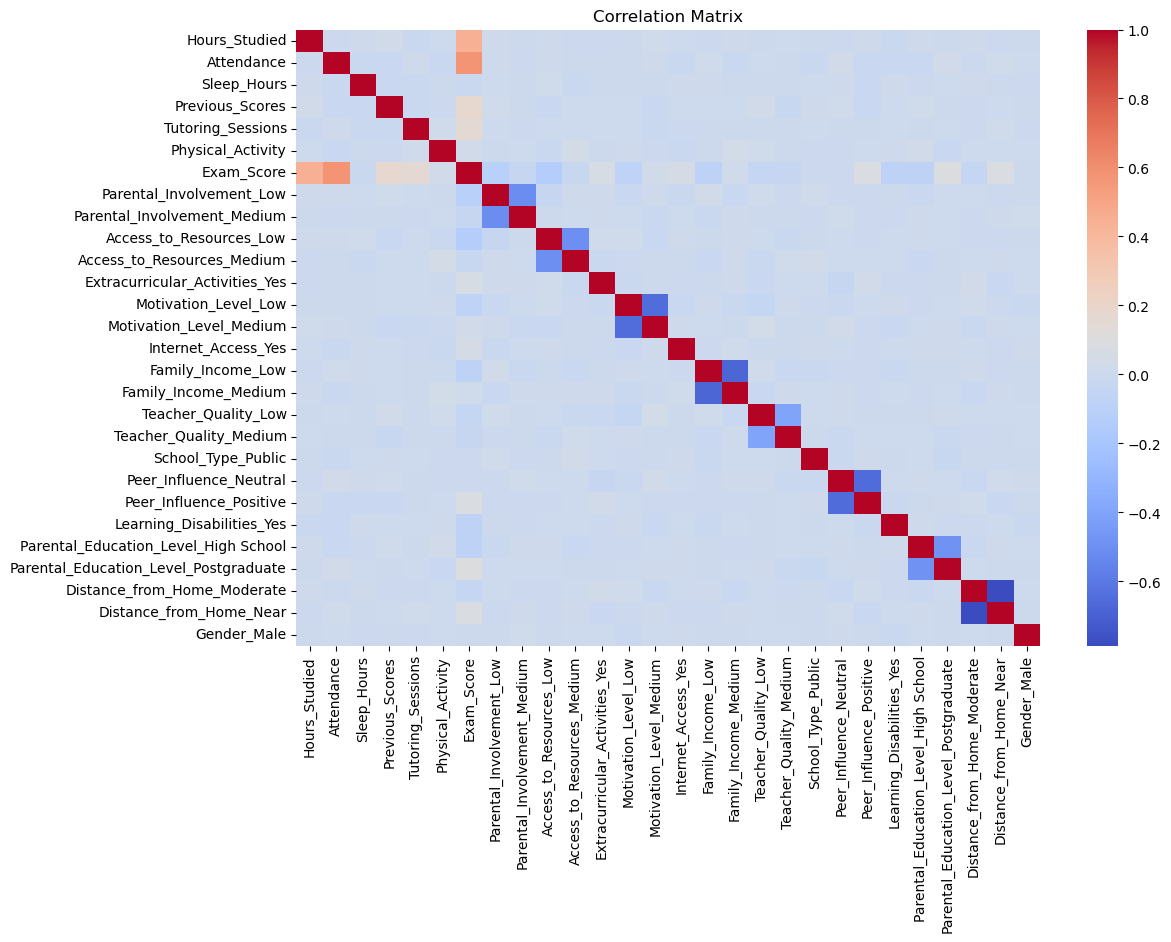

In [49]:
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()                        # coolwarm → Red = positive, Blue = negative

### (c.iii) Identify Variables Highly Related to Target
### (We don’t need all relationships.We care about:Which variables affect Exam_Score?)

In [51]:
correlation_with_target = correlation_matrix["Exam_Score"].sort_values(ascending=False)
correlation_with_target

Exam_Score                               1.000000
Attendance                               0.581072
Hours_Studied                            0.445455
Previous_Scores                          0.175079
Tutoring_Sessions                        0.156525
Parental_Education_Level_Postgraduate    0.093764
Distance_from_Home_Near                  0.084870
Peer_Influence_Positive                  0.081217
Extracurricular_Activities_Yes           0.064382
Internet_Access_Yes                      0.051475
Physical_Activity                        0.027824
Motivation_Level_Medium                  0.024771
Family_Income_Medium                     0.020995
Gender_Male                             -0.002032
Peer_Influence_Neutral                  -0.007795
School_Type_Public                      -0.008844
Sleep_Hours                             -0.017022
Access_to_Resources_Medium              -0.026158
Parental_Involvement_Medium             -0.035978
Teacher_Quality_Medium                  -0.039294


### (c.iii) Comment on the results.

##### The correlation analysis indicates that Attendance (0.58) and Hours_Studied (0.45) have moderate positive relationships with Exam_Score, suggesting that students who attend classes regularly and dedicate more time to studying tend to achieve better academic performance. Most other variables show weak correlations, indicating that exam performance is influenced by multiple factors rather than a single dominant variable. Some negative correlations, such as Access_to_Resources_Low and Parental_Involvement_Low, suggest that limited academic support and resources may negatively affect student performance.

## (d) Split the Dataset into Training and Testing Sets

### (d.i) Split the dataset into training and testing sets.

In [54]:
from sklearn.model_selection import train_test_split  #here we import splitting function

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, 
    y, 
    test_size=0.3, #30% for testing other for training
    random_state=42
)

### Confirm the Split

In [55]:
print("Training Features Shape:", X_train.shape) #comes in form of rows & colm, column is after encoding(4624 rows for training)
print("Testing Features Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)  

Training Features Shape: (4624, 27)
Testing Features Shape: (1983, 27)
Training Target Shape: (4624,)
Testing Target Shape: (1983,)


## (e) Build a Machine Learning Model

### (e.i) Select a suitable classification or regression algorithm.

Since target variable Exam_Score is numerical.This is a Regression problem, not Classification.Hence we will use **Linear Regression**

### (e.ii)Train the model using the training data.

In [59]:
from sklearn.linear_model import LinearRegression
model = LinearRegression() #Our regression object
model.fit(X_train, y_train) #Training is called fitting.

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Check the Coefficients, in which modal thinks they are importants 

In [61]:
coefficients = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])
coefficients    #  +ve Increases exam score

,Coefficient
Hours_Studied,1.747585
Attendance,2.301828
Sleep_Hours,-0.028550
Previous_Scores,0.719156
Tutoring_Sessions,0.629438
Physical_Activity,0.184606
Parental_Involvement_Low,-0.794517
Parental_Involvement_Medium,-0.537345
Access_to_Resources_Low,-0.836557
Access_to_Resources_Medium,-0.527658


## (f) Model Evaluation

### (f.i) Test the model using test data.

In [67]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
y_test_pred = model.predict(X_test)

### Calculate performance metrics 

In [70]:
rmse = np.sqrt(mse)  # Square root of MSE
r2 = r2_score(y_test, y_test_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 0.452581934391431
Mean Squared Error (MSE): 3.111721208021323
Root Mean Squared Error (RMSE): 1.7640071451162898
R² Score: 0.773527823292345


##### intrepretation of results

The evaluation results indicate that the developed model performs well in predicting student performance. The mean absolute error of 0.45 shows that predictions are generally very close to the actual values. The root mean squared error of 1.76 indicates that large prediction errors are limited. Furthermore, the R² score of 0.77 demonstrates that approximately 77% of the variability in student performance is explained by the model, suggesting strong predictive capability.

## (g) Prediction and Interpretation

### (g.i) Use the model to make new predictions.


#### Pick New Students

In [71]:
# Pick row 0 and row 1 as new students
new_students_df = df.iloc[[0, 1]].drop("Exam_Score", axis=1)

#### Encode Categorical Variables

In [72]:
# One-hot encode categorical columns
new_students_encoded = pd.get_dummies(new_students_df)

#### Align Columns with Training Data

In [73]:
# Add missing columns with 0
for col in X.columns:
    if col not in new_students_encoded.columns:
        new_students_encoded[col] = 0

# Reorder columns to match training features
new_students_encoded = new_students_encoded[X.columns]

#### Scale the Features

In [74]:
new_students_scaled = scaler.transform(new_students_encoded)

#### Predict Exam Scores

In [75]:
predicted_scores = model.predict(new_students_scaled)
print("Predicted Exam Scores for new students:", predicted_scores)

Predicted Exam Scores for new students: [67.1912154  60.76706359]


### (g.ii)Explain what the predictions mean in real life.

Based on this student’s study hours, attendance, motivation level, parental involvement, and other factors, the model predicts that the student will score approximately 67 and 61 in the exam. This information can help teachers or parents identify if the student is performing as expected and whether additional support may be needed.

## (h) Conclusion and Recommendation

### conclusion

In this project, a Linear Regression model was developed to predict students’ exam scores based on factors such as study hours, attendance, previous scores, sleep hours, and motivation level.
The results showed that the model can reasonably predict exam performance. Study hours, attendance, and previous scores were found to have strong influence on exam results.
This shows that academic performance can be estimated using measurable student-related factors

### Recommendation

To improve model performance in the future:

-> we need to use a larger and more diverse dataset.

-> To Include more important factors (e.g., stress level, teaching quality, family background).

-> To Try more advanced models such as Random Forest or XGBoost.

-> To Perform further tuning and cross-validation to improve accuracy.